In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dropout

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model = Sequential([
    Flatten(input_shape=(28, 28)),     # Convert 28x28 image into 784 features
    Dense(64, activation='relu'),     # Hidden layer
    #Dense(64, activation='relu'), 
    Dense(10, activation='softmax')    # Output layer (10 classes)
])

model.summary()

c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8492 - loss: 0.5440 - val_accuracy: 0.9479 - val_loss: 0.1854
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 980us/step - accuracy: 0.9508 - loss: 0.1712 - val_accuracy: 0.9564 - val_loss: 0.1502
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 952us/step - accuracy: 0.9649 - loss: 0.1190 - val_accuracy: 0.9639 - val_loss: 0.1235
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 959us/step - accuracy: 0.9721 - loss: 0.0920 - val_accuracy: 0.9680 - val_loss: 0.1109
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 941us/step - accuracy: 0.9784 - loss: 0.0761 - val_accuracy: 0.9698 - val_loss: 0.1037
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 960us/step - accuracy: 0.9819 - loss: 0.0610 - val_accuracy: 0.9717 - val_loss: 0.0955
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 960us/step - accuracy: 0.9861 - loss: 0.0493 - val_accuracy: 0.9672 - val_loss: 0.1108
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 949us/step - accuracy: 0.9868 - l

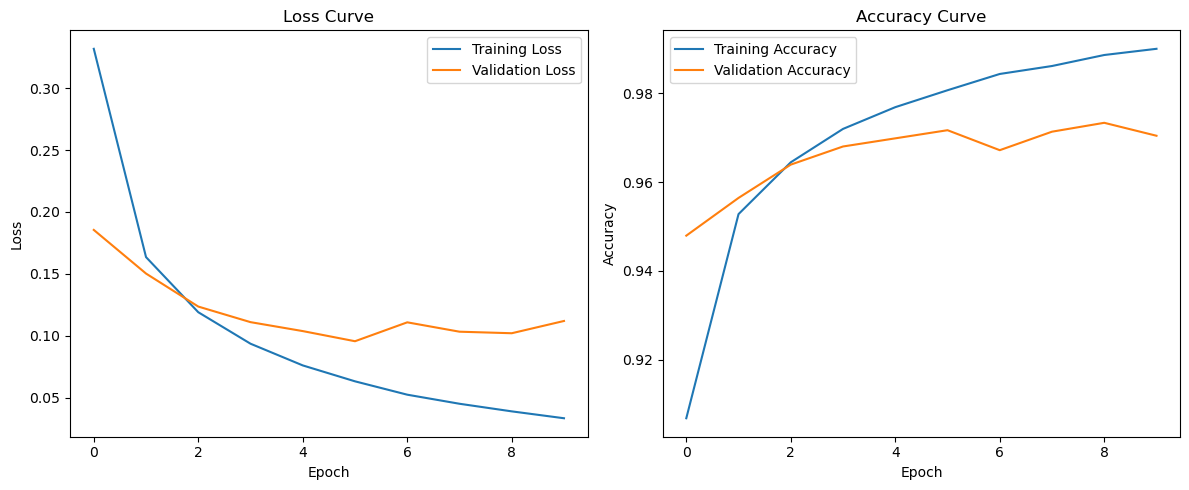

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()